<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES20Force004.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
grid_size = 512
e_folds = 10000
beta_color = 1/9  # Hypothetical SU(3) coupling


In [2]:
def generate_spinor_triplet(grid_size):
    x = np.linspace(0, 4*np.pi, grid_size)
    y = np.linspace(0, 4*np.pi, grid_size)
    X, Y = np.meshgrid(x, y)
    red   = np.sin(X) * np.sin(2*Y)
    green = np.sin(X + np.pi/3) * np.sin(2*Y + np.pi/3)
    blue  = np.sin(X + 2*np.pi/3) * np.sin(2*Y + 2*np.pi/3)
    return red, green, blue


In [3]:
def color_coupling(red, green, blue, beta=1/9):
    # Phase differences
    grad_r_x, grad_r_y = np.gradient(red)
    grad_g_x, grad_g_y = np.gradient(green)
    grad_b_x, grad_b_y = np.gradient(blue)

    theta_r = np.arctan2(grad_r_y, grad_r_x)
    theta_g = np.arctan2(grad_g_y, grad_g_x)
    theta_b = np.arctan2(grad_b_y, grad_b_x)

    # Coupling terms
    coupling_rg = -beta * np.sin(theta_r - theta_g)
    coupling_gb = -beta * np.sin(theta_g - theta_b)
    coupling_br = -beta * np.sin(theta_b - theta_r)

    # Apply coupling
    red   += coupling_br
    green += coupling_rg
    blue  += coupling_gb

    return red, green, blue


In [5]:
def evolve_field(field, steps, decay=0.9999):
    evolved = field.copy()
    for _ in range(steps):
        evolved *= decay
        evolved += np.random.normal(0, 0.001, field.shape)
    return evolved


In [6]:
def memory_fidelity(original, evolved):
    return np.corrcoef(original.flatten(), evolved.flatten())[0,1]


Red fidelity:   0.9426
Green fidelity: 0.9433
Blue fidelity:  0.9432


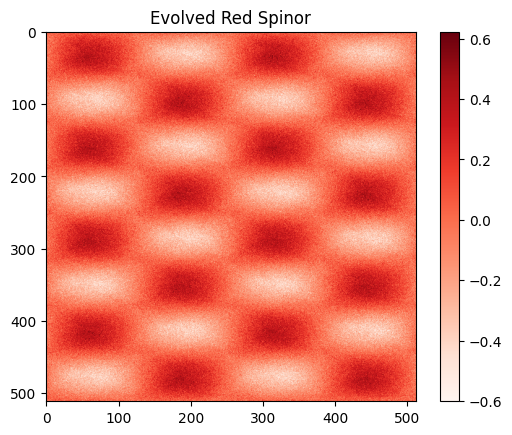

In [7]:
red, green, blue = generate_spinor_triplet(grid_size)
red_c, green_c, blue_c = color_coupling(red, green, blue, beta_color)

red_e   = evolve_field(red_c, e_folds)
green_e = evolve_field(green_c, e_folds)
blue_e  = evolve_field(blue_c, e_folds)

f_r = memory_fidelity(red_c, red_e)
f_g = memory_fidelity(green_c, green_e)
f_b = memory_fidelity(blue_c, blue_e)

print(f"Red fidelity:   {f_r:.4f}")
print(f"Green fidelity: {f_g:.4f}")
print(f"Blue fidelity:  {f_b:.4f}")

plt.imshow(red_e, cmap='Reds')
plt.title("Evolved Red Spinor")
plt.colorbar()
plt.show()
